# Task - Predicția prețului mașinilor second-hand

**Încărcarea și explorarea datelor**

In [91]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [92]:
DATA_PATH = Path("../data/cars.csv")
df = pd.read_csv(DATA_PATH)

*Afisarea primelor randuri*

In [93]:
df.head()

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


*Numărul de rânduri și coloane*

In [94]:
df.shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 56244
Columns: 12


*Afisarea denumirii coloanelor*

In [95]:
df.columns.tolist()

['make',
 'model',
 'priceUSD',
 'year',
 'condition',
 'mileage(kilometers)',
 'fuel_type',
 'volume(cm3)',
 'color',
 'transmission',
 'drive_unit',
 'segment']

*Informatii despre coloane*

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 8.3 MB


Tipurile de date

Avem:

* 4 coloane numerice:
    * priceUSD
    * year
    * mileage(kilometers)
    * volume(cm3)
* 8 coloane categorice:
    * make
    * model
    * condition
    * fuel_type
    * color
    * transmission
    * drive_unit
    * segment

*Analiza coloanelor numerice*

In [97]:
numeric_columns = [
    "priceUSD",
    "year",
    "mileage(kilometers)",
    "volume(cm3)"
]

df[numeric_columns].dtypes

priceUSD                 int64
year                     int64
mileage(kilometers)    float64
volume(cm3)            float64
dtype: object

In [98]:
df[numeric_columns].describe()

,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


*Analiza coloanelor categoriale*

In [99]:
categorical_columns = [
    "make",
    "model",
    "condition",
    "fuel_type",
    "color",
    "transmission",
    "drive_unit",
    "segment"
]

for column in categorical_columns:
    print(column)
    print(df[column].nunique())
    print("-" * 40)

make
96
----------------------------------------
model
1034
----------------------------------------
condition
3
----------------------------------------
fuel_type
3
----------------------------------------
color
13
----------------------------------------
transmission
2
----------------------------------------
drive_unit
4
----------------------------------------
segment
9
----------------------------------------


In [100]:
for column in categorical_columns:
    print(column)
    print(df[column].value_counts(dropna=False))
    print("-" * 40)

make
make
volkswagen    6861
audi          4030
bmw           4013
opel          3779
renault       3713
              ... 
trabant          1
jac              1
asia             1
tagaz            1
saipa            1
Name: count, Length: 96, dtype: int64
----------------------------------------
model
model
passat      2086
5-seriya    1476
a6          1276
golf        1070
astra       1013
            ... 
xb             1
xc40           1
xjs            1
xt5            1
z3             1
Name: count, Length: 1034, dtype: int64
----------------------------------------
condition


condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64
----------------------------------------
fuel_type
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64
----------------------------------------
color
color
black       12385
silver      10075
blue         8083
gray         5807
white        5292
green        3911
other        3397
red          2744
burgundy     2026
brown        1349
purple        625
yellow        317
orange        233
Name: count, dtype: int64
----------------------------------------
transmission
transmission
mechanics    36056
auto         20188
Name: count, dtype: int64
----------------------------------------
drive_unit
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive                5890
part-time four-wheel drive     3597
NaN                            1905
Name: count, dtype: int64
--------------------------------------

*Valori lipsa*

In [101]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

volume(cm3)      47
drive_unit     1905
segment        5291
dtype: int64

*Verificarea valorilor lipsa sub forma de text*

In [102]:
missing_like_values = ["NaN", "nan", "NULL", "null", "None", "none", "", " "]

for column in df.columns:
    if df[column].dtype == "object":
        count = df[column].astype(str).str.strip().isin(missing_like_values).sum()
       
        if count > 0:
            print(f"{column}: {count}")

*Verificare duplicate*

In [103]:
df.duplicated().sum()

np.int64(87)

**Analiza variabilei țintă**

In [104]:
df["priceUSD"].head()

0    5500
1    5350
2    7000
3    3300
4    5200
Name: priceUSD, dtype: int64

In [105]:
df["priceUSD"].dtype

dtype('int64')

In [106]:
df["priceUSD"].unique()[:30]

array([5500, 5350, 7000, 3300, 5200, 3400, 5000, 7300, 6400, 6132, 3299,
       5400, 6850, 5300, 5670, 5950, 3500, 5600, 6500, 3200, 3550, 9800,
       4200, 8300, 7500, 5800, 6300, 6700, 4650, 4754])

In [107]:
df["priceUSD"].describe()

count     56244.000000
mean       7415.456440
std        8316.959261
min          48.000000
25%        2350.000000
50%        5350.000000
75%        9807.500000
max      235235.000000
Name: priceUSD, dtype: float64

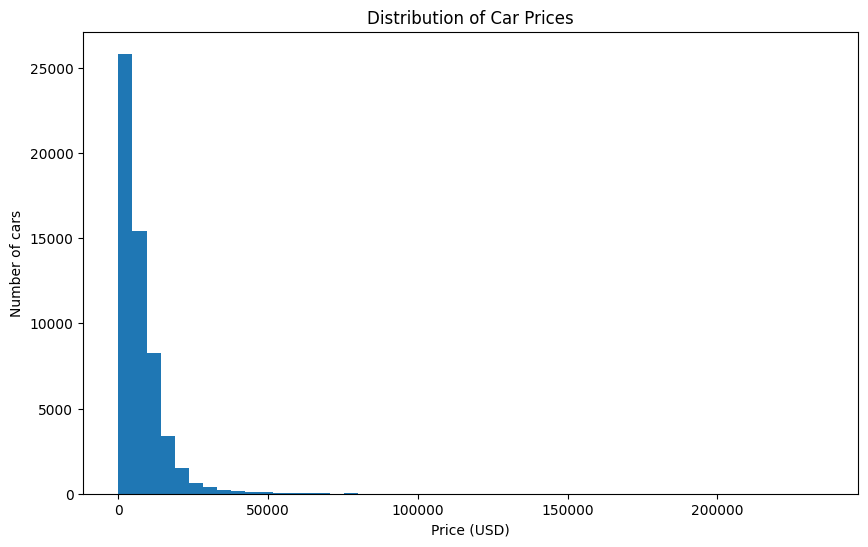

In [108]:
plt.figure(figsize=(10, 6))

plt.hist(df["priceUSD"], bins=50)

plt.xlabel("Price (USD)")
plt.ylabel("Number of cars")
plt.title("Distribution of Car Prices")

plt.show()

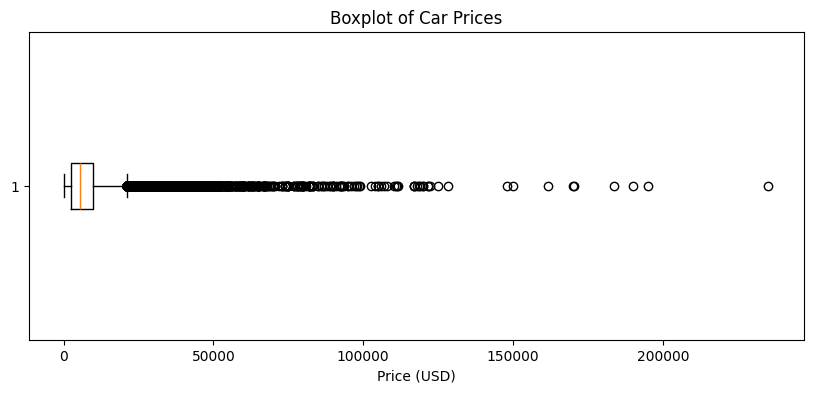

In [109]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["priceUSD"], vert=False)

plt.xlabel("Price (USD)")
plt.title("Boxplot of Car Prices")

plt.show()

Distribuția variabilei priceUSD este puternic asimetrică spre dreapta. Majoritatea mașinilor din dataset au prețuri relativ mici, în timp ce există un număr mai redus de mașini cu prețuri foarte mari.

Valoarea medie a prețului este de aproximativ 7.415 USD, iar mediana este 5.350 USD, ceea ce confirmă influența valorilor mari asupra mediei. Prețul minim este de 48 USD, iar cel maxim ajunge la 235.235 USD.

Boxplot-ul evidențiază numeroase valori extreme, în special la prețurile ridicate. Aceste observații vor fi analizate în continuare pentru a determina dacă reprezintă valori reale sau posibile erori în date.

**Valorile extreme**

*Primele 10 cele mai ieftine masini*

In [110]:
df.sort_values("priceUSD").head(10)

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
5952,zaz,968,48,1910,with damage,25000.0,petrol,1100.0,green,mechanics,rear drive,B
40252,proton,persona,95,1997,with damage,1111.0,petrol,1600.0,burgundy,mechanics,front-wheel drive,NaN
24873,ford,fiesta,100,1992,for parts,1.0,petrol,1100.0,blue,mechanics,front-wheel drive,B
20971,toyota,corolla,100,1988,for parts,300000.0,petrol,1300.0,red,mechanics,front-wheel drive,C
41010,nissan,primera,100,1994,for parts,300000.0,petrol,2000.0,burgundy,mechanics,front-wheel drive,D
7314,mercedes-benz,190-w201,100,1991,for parts,2000.0,petrol,2000.0,black,mechanics,NaN,D
54171,citroen,xantia,100,1995,for parts,380000.0,petrol,1800.0,silver,mechanics,front-wheel drive,D
5456,mazda,626,100,1986,with mileage,100.0,petrol,2000.0,gray,mechanics,front-wheel drive,C
23898,ford,escort,100,1986,for parts,200000.0,petrol,1300.0,blue,mechanics,front-wheel drive,C
7076,lada-vaz,21099,119,1992,for parts,20000.0,petrol,1500.0,green,mechanics,front-wheel drive,B


*Primele 10 cele mai scumpe masini*

In [111]:
df.sort_values("priceUSD", ascending=False).head(10)

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
20787,bentley,continental-gt,235235,2018,with mileage,29000.0,petrol,6000.0,white,auto,all-wheel drive,NaN
16430,bentley,bentayga,195000,2016,with mileage,72000.0,petrol,6000.0,other,auto,all-wheel drive,NaN
35457,bentley,mulsanne,190141,2014,with mileage,36500.0,petrol,6750.0,purple,auto,rear drive,NaN
16428,bentley,bentayga,183848,2016,with mileage,22000.0,petrol,6000.0,silver,auto,all-wheel drive,NaN
16429,bentley,bentayga,170477,2016,with mileage,74100.0,petrol,6000.0,other,auto,all-wheel drive,NaN
19557,porsche,cayenne,170000,2018,with mileage,1020.0,petrol,4000.0,black,auto,all-wheel drive,J
34508,tesla,model-x,161563,2019,with mileage,50.0,electrocar,NaN,white,auto,part-time four-wheel drive,NaN
26254,mercedes-benz,g-klass,150000,2001,with mileage,160000.0,petrol,5000.0,yellow,auto,part-time four-wheel drive,J
33702,mercedes-benz,maybach,148000,2019,with mileage,950.0,petrol,3000.0,black,auto,all-wheel drive,NaN
33327,bmw,m5,128136,2019,with mileage,2925.0,petrol,4400.0,gray,auto,part-time four-wheel drive,NaN


In [112]:
Q1 = df["priceUSD"].quantile(0.25)
Q3 = df["priceUSD"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 2350.0
Q3: 9807.5
IQR: 7457.5
Lower bound: -8836.25
Upper bound: 20993.75


In [113]:
outliers = df[
    (df["priceUSD"] < lower_bound) |
    (df["priceUSD"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))
print("Percentage:", len(outliers) / len(df) * 100)

Number of potential outliers: 2551
Percentage: 4.535594907901287


Pentru identificarea valorilor extreme am folosit metoda IQR (Interquartile Range). Q1 este 2.350 USD, iar Q3 este 9.807,50 USD, rezultând un IQR de 7.457,50 USD. Conform acestei metode, valorile mai mari de aproximativ 20.994 USD sunt considerate potențiali outlieri.

Au fost identificate 2.551 de observații, reprezentând aproximativ 4,54% din dataset. Limita inferioară rezultată este negativă, astfel încât aceasta nu prezintă relevanță practică pentru prețuri.



## Lista problemelor pentru etapa de curățare

* denumirile coloanelor trebuie standardizate;

* un anumit număr de coloane conțin valori lipsă, astfel încât va trebui să decidem dacă le eliminăm sau dacă le completăm ulterior folosind o strategie adecvată;

* schimbarea tipului numeric din float in numar intreg a coloanei volume(cm3).